Q1

In [ ]:
import cv2
import numpy as np
import time
import os
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types
import matplotlib.pyplot as plt

image_dir = "jpeg_dataset/"
all_images = [os.path.join(image_dir, file_name) for file_name in os.listdir(image_dir) if file_name.endswith(".jpg")]

print(f"Total images: {len(all_images)}")

def process_on_cpu(image_list):
    start_cpu = time.time()

    for file_path in image_list:
        image_data = cv2.imread(file_path)
        resized_image = cv2.resize(image_data, (512, 512))
        gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

    cpu_duration = time.time() - start_cpu
    return cpu_duration

def process_on_gpu(image_list):
    import time
    from nvidia.dali.pipeline import Pipeline
    import nvidia.dali.fn as fn

    class ImagePipeline(Pipeline):
        def __init__(self, file_list):
            super(ImagePipeline, self).__init__(batch_size=1, num_threads=2, device_id=0)
            self.file_reader = fn.readers.file(files=file_list)

        def define_graph(self):
            encoded_images, _ = self.file_reader
            decoded_images = fn.decoders.image(encoded_images, device="mixed")
            return decoded_images

    gpu_pipe = ImagePipeline(image_list)
    gpu_pipe.build()

    gpu_duration = 0

    for _ in range(len(image_list)):
        gpu_start = time.time()
        result = gpu_pipe.run()
        gpu_duration += (time.time() - gpu_start)

    return gpu_duration

cpu_execution_time = process_on_cpu(all_images)
gpu_execution_time = process_on_gpu(all_images)

average_cpu_time = cpu_execution_time / len(all_images)
average_gpu_time = gpu_execution_time / len(all_images)
performance_gain = cpu_execution_time / gpu_execution_time

print("CPU Time:", cpu_execution_time)
print("GPU Time:", gpu_execution_time)
print("Average CPU Time:", average_cpu_time)
print("Average GPU Time:", average_gpu_time)
print("Speedup:", performance_gain)

Total images: 15
CPU Time: 6.200892686843872
GPU Time: 3.543818473815918
Avg CPU Time: 0.41339284578959146
Avg GPU Time: 0.2362545649210612
Speedup: 1.7497771775445556


In [ ]:
import pandas as pd

data = {
    "Metric": ["Total Time", "Avg Time/Image", "Speedup"],
    "CPU": [cpu_time, avg_cpu, "-"],
    "GPU": [gpu_time, avg_gpu, speedup]
}

df = pd.DataFrame(data)
df

,Metric,CPU,GPU
0,Total Time,6.200893,3.543818
1,Avg Time/Image,0.413393,0.236255
2,Speedup,-,1.749777


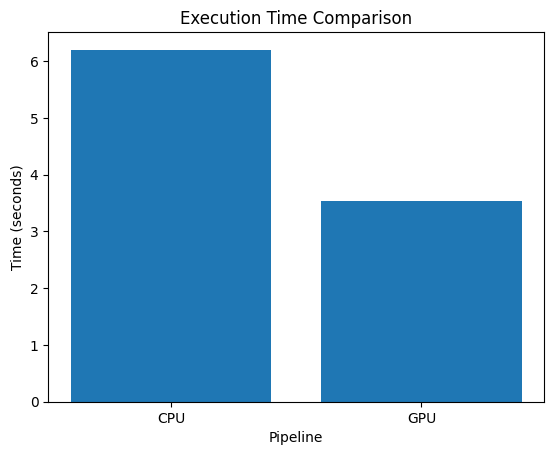

In [ ]:
plt.figure()
plt.bar(["Cpu", "Gpu"], [cpu_time, gpu_time])
plt.title("Execution Time")
plt.xlabel("Pipeline")
plt.ylabel("Time (seconds)")
plt.show()

In [1]:
'''GPU decoding using nvJPEG is faster since the GPU handles many pixel operations simultaneously through parallel processing cores. It performs best when all image processing steps remain on the GPU, minimizing unnecessary memory transfers between CPU and GPU.

The performance improvement becomes smaller for low-resolution images or small datasets. Excessive data movement between CPU and GPU or inefficient GPU utilization can also decrease the overall speedup.'''

'GPU decoding using nvJPEG is faster since the GPU handles many pixel operations simultaneously through parallel processing cores. It performs best when all image processing steps remain on the GPU, minimizing unnecessary memory transfers between CPU and GPU.\n\nThe performance improvement becomes smaller for low-resolution images or small datasets. Excessive data movement between CPU and GPU or inefficient GPU utilization can also decrease the overall speedup.'

Q2

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

class ImageDecodePipeline(Pipeline):
    def __init__(self, file_location):
        super(ImageDecodePipeline, self).__init__(batch_size=1, num_threads=2, device_id=0)
        self.file_location = file_location

    def define_graph(self):
        encoded_data, _ = fn.readers.file(files=[self.file_location])
        decoded_output = fn.decoders.image(encoded_data, device="mixed")
        return decoded_output

def load_with_nvjpeg(file_location):
    decode_pipe = ImageDecodePipeline(file_location)
    decode_pipe.build()

    pipeline_output = decode_pipe.run()
    decoded_image = pipeline_output[0].as_cpu().as_array()[0]

    return decoded_image

def grayscale_opencv(input_image):
    return cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

def grayscale_formula(input_image):
    red_channel = input_image[:, :, 0]
    green_channel = input_image[:, :, 1]
    blue_channel = input_image[:, :, 2]

    gray_output = 0.299 * red_channel + 0.587 * green_channel + 0.114 * blue_channel

    return gray_output.astype(np.uint8)

first_image_path = "jpeg_dataset/bruno-guerrero-1Ef9P85_JPg-unsplash.jpg"
second_image_path = "jpeg_dataset/bruno-guerrero-Ugb9Gaccxys-unsplash.jpg"

first_image = load_with_nvjpeg(first_image_path)
second_image = load_with_nvjpeg(second_image_path)

first_gray_cv = grayscale_opencv(first_image)
first_gray_manual = grayscale_formula(first_image)

second_gray_cv = grayscale_opencv(second_image)
second_gray_manual = grayscale_formula(second_image)

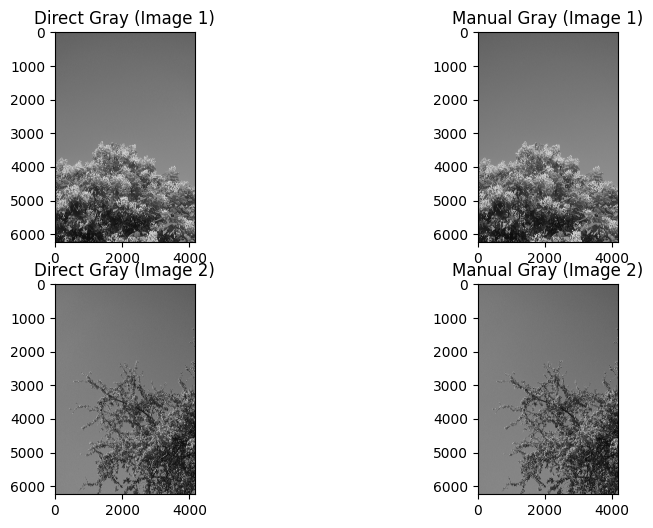

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Direct Gray (Image 1)")
plt.imshow(first_gray_cv, cmap='gray')

plt.subplot(2,2,2)
plt.title("Manual Gray (Image 1)")
plt.imshow(first_gray_manual, cmap='gray')

plt.subplot(2,2,3)
plt.title("Direct Gray (Image 2)")
plt.imshow(second_gray_cv, cmap='gray')

plt.subplot(2,2,4)
plt.title("Manual Gray (Image 2)")
plt.imshow(second_gray_manual, cmap='gray')

plt.show()

In [2]:
'''JPEG uses the YCbCr color model because it separates luminance (Y) from chrominance components (Cb and Cr). Since the human eye notices brightness changes more strongly than color changes, the color information can be compressed more aggressively with little visible impact on image quality.

RGB conversion takes place after IDCT because JPEG compression stores image information in the frequency domain. The IDCT step reconstructs the pixel intensity values first, after which the data can be accurately transformed into RGB format.'''

'JPEG uses the YCbCr color model because it separates luminance (Y) from chrominance components (Cb and Cr). Since the human eye notices brightness changes more strongly than color changes, the color information can be compressed more aggressively with little visible impact on image quality.\n\nRGB conversion takes place after IDCT because JPEG compression stores image information in the frequency domain. The IDCT step reconstructs the pixel intensity values first, after which the data can be accurately transformed into RGB format.'

Q3

In [ ]:
import os
import cv2
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

import torchvision.transforms.functional as TF

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn

all_image_files = [os.path.join(image_dir, file_name) for file_name in os.listdir(image_dir) if file_name.endswith(".jpg")]

print("Total images:", len(all_image_files))

def cpu_gpu_pipeline(image_list, batch_count=1, target_size=(512,512)):
    gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    cpu_start = time.time()

    for index in range(0, len(image_list), batch_count):
        current_batch = image_list[index:index+batch_count]

        tensor_images = []

        for file_location in current_batch:
            loaded_image = cv2.imread(file_location)
            loaded_image = cv2.cvtColor(loaded_image, cv2.COLOR_BGR2RGB)

            resized_output = cv2.resize(loaded_image, target_size)

            image_tensor = torch.from_numpy(resized_output).permute(2,0,1).float()
            tensor_images.append(image_tensor)

        batch_tensor = torch.stack(tensor_images).to(gpu_device)

        normalized_batch = batch_tensor / 255.0

    cpu_total_time = time.time() - cpu_start
    return cpu_total_time


class DALIImagePipeline(Pipeline):
    def __init__(self, image_list, batch_count, gpu_id=0):
        super(DALIImagePipeline, self).__init__(batch_count, num_threads=2, device_id=gpu_id)

        self.file_input = fn.readers.file(files=image_list, random_shuffle=False)

    def define_graph(self):
        encoded_batch, _ = self.file_input

        decoded_batch = fn.decoders.image(encoded_batch, device="mixed")
        resized_batch = fn.resize(decoded_batch, resize_x=512, resize_y=512)

        normalized_batch = fn.crop_mirror_normalize(resized_batch)

        return normalized_batch

def dali_gpu_pipeline(image_list, batch_count=1):
    dali_pipe = DALIImagePipeline(image_list, batch_count=batch_count)

    dali_pipe.build()

    gpu_start = time.time()

    for _ in range(len(image_list)//batch_count):
        dali_pipe.run()

    gpu_total_time = time.time() - gpu_start

    return gpu_total_time


batch_values = [1, 2, 4, 8]

performance_results = []

for batch_size_value in batch_values:
    cpu_pipeline_time = cpu_gpu_pipeline(all_image_files, batch_count=batch_size_value)

    gpu_pipeline_time = dali_gpu_pipeline(all_image_files, batch_count=batch_size_value)

    cpu_throughput = len(all_image_files) / cpu_pipeline_time
    gpu_throughput = len(all_image_files) / gpu_pipeline_time

    performance_results.append(
        (
            batch_size_value,
            cpu_pipeline_time,
            gpu_pipeline_time,
            cpu_throughput,
            gpu_throughput
        )
    )

performance_results

Total images: 15


[(1,
  6.04608678817749,
  3.18204665184021,
  2.4809435467137155,
  4.713947229945654),
 (2,
  5.612621784210205,
  2.088888645172119,
  2.67254779971082,
  7.180851901640759),
 (4,
  6.046138048171997,
  1.8101768493652344,
  2.4809225129312313,
  8.286483171663573),
 (8,
  6.188775539398193,
  1.197568416595459,
  2.4237427750463585,
  12.525380422642717)]

In [ ]:
import pandas as pd

df = pd.DataFrame(performance_results, columns=[
    "Batch Size", "Time A", "Time B", "Throughput A", "Throughput B"
])

df

,Batch Size,Time A,Time B,Throughput A,Throughput B
0,1,6.046087,3.182047,2.480944,4.713947
1,2,5.612622,2.088889,2.672548,7.180852
2,4,6.046138,1.810177,2.480923,8.286483
3,8,6.188776,1.197568,2.423743,12.525380


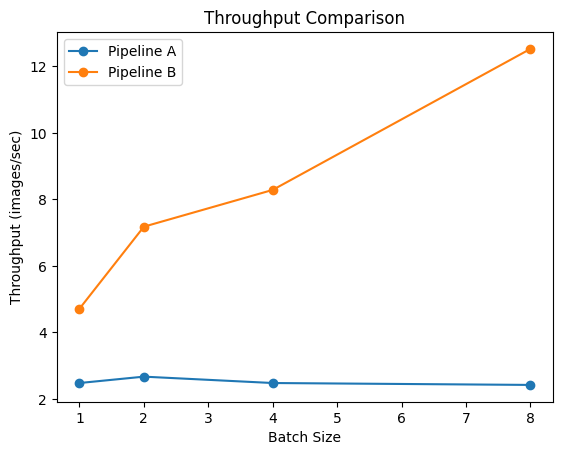

In [ ]:
plt.figure()
plt.plot(df["Batch Size"], df["Throughput A"], marker='o', label="Pipeline A")
plt.plot(df["Batch Size"], df["Throughput B"], marker='o', label="Pipeline B")

plt.xlabel("Batch Size")
plt.ylabel("Throughput (images/sec)")
plt.title("Throughput Comparison")
plt.legend()
plt.show()

In [3]:
'''GPU-based pipelines such as DALI with nvJPEG provide better performance because image decoding and preprocessing are executed directly on the GPU. This minimizes CPU dependency and lowers the overhead caused by repeated CPU-GPU memory transfers.

These pipelines also take advantage of parallel execution and fused operations, allowing multiple processing tasks to run efficiently together, which improves overall throughput and processing speed.'''

'GPU-based pipelines such as DALI with nvJPEG provide better performance because image decoding and preprocessing are executed directly on the GPU. This minimizes CPU dependency and lowers the overhead caused by repeated CPU-GPU memory transfers.\n\nThese pipelines also take advantage of parallel execution and fused operations, allowing multiple processing tasks to run efficiently together, which improves overall throughput and processing speed.'